In [1]:
! pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\goodw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/california-housing-prices/housing.csv")

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info() #overview of data with column names and number of not null data and datatype

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
df['ocean_proximity'].value_counts() #gives the categories and the number of rows in each category

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


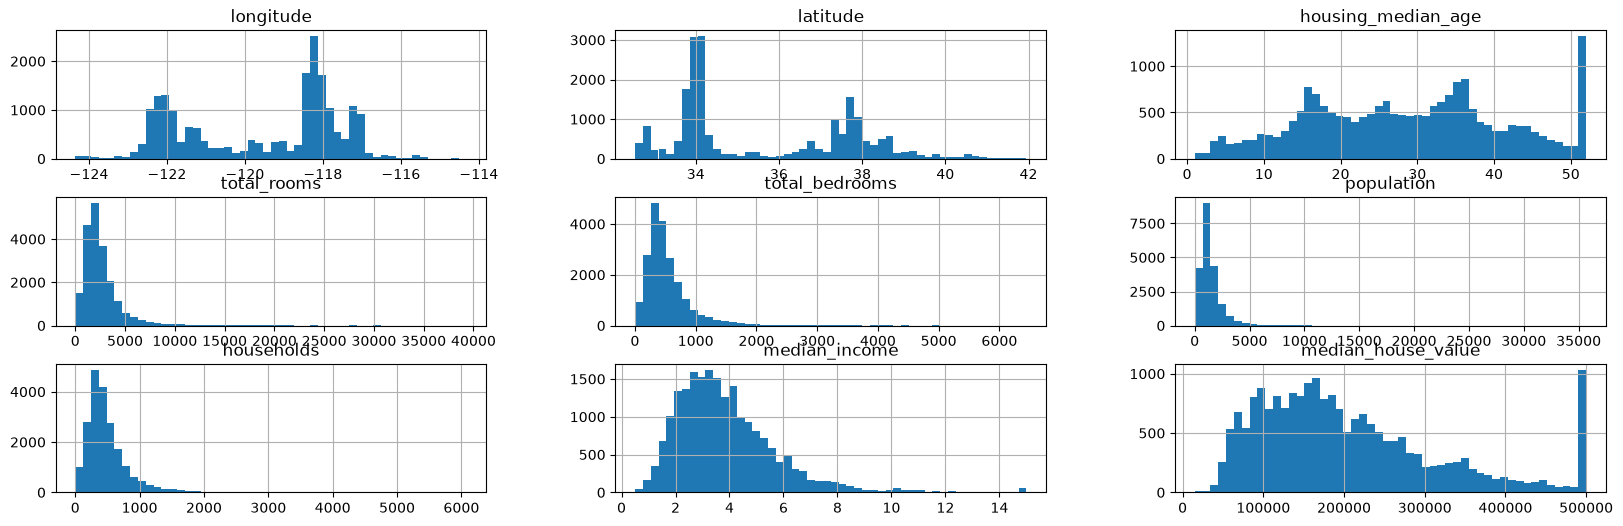

In [7]:
df.hist(bins=50, figsize=(20,6))
plt.show()

In [8]:
X = df.loc[:, ["longitude", "latitude" ,          
    "total_rooms" ,         
    "total_bedrooms" ,    
    "population",          
    "households",          
    "median_income",       
    "housing_median_age",  
   "ocean_proximity" ]]

    

In [9]:
y = df.loc[:,"median_house_value"] 

In [10]:
from sklearn.model_selection import train_test_split
train_set , test_set = train_test_split(df, random_state=42, test_size=0.2) 

In [11]:
#under the hood for doing a train test split
import numpy as np
def shuffle_and_split_data(data, test_ratio):
    shuffle_indices = np.random.permutation(len(data)) #array of 10 random indices 
    test_shuffle_indices = int(len(data)*test_ratio) #gives value
    test_indices = shuffle_indices[:test_shuffle_indices]
    train_indices = shuffle_indices[test_shuffle_indices:]
    return data.iloc[test_indices], data.iloc[train_indices]

test_data , train_data = shuffle_and_split_data(df, 0.2)





In [12]:
print(test_data)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
18154    -122.05     37.36                27.0       2621.0           513.0   
7275     -118.24     33.99                33.0        885.0           294.0   
18951    -122.05     38.25                37.0       1336.0           251.0   
4943     -118.28     34.02                46.0       1098.0           426.0   
18963    -122.04     38.27                16.0       8517.0          1910.0   
...          ...       ...                 ...          ...             ...   
19638    -120.97     37.43                27.0       1380.0             NaN   
6859     -118.15     34.05                31.0       3362.0           799.0   
10543    -117.70     33.68                29.0       5650.0          1084.0   
10270    -117.87     33.87                 7.0       2663.0           642.0   
14464    -117.23     32.81                24.0       3271.0           508.0   

       population  households  median_income  media

In [13]:
print(train_data)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
3651     -118.44     34.21                41.0       1440.0           325.0   
7521     -118.26     33.91                39.0        967.0           256.0   
2918     -119.04     35.36                40.0       1533.0           312.0   
17158    -122.21     37.42                28.0        564.0            72.0   
20381    -118.83     34.14                16.0       1956.0           312.0   
...          ...       ...                 ...          ...             ...   
8046     -118.17     33.84                45.0       1533.0           331.0   
12258    -116.95     33.79                 8.0      10997.0          2205.0   
3476     -118.52     34.32                18.0       7498.0           976.0   
7570     -118.21     33.89                42.0       1254.0           225.0   
18348    -122.15     37.41                15.0       2577.0           360.0   

       population  households  median_income  media

In [14]:
#to get test set by hashes
from zlib import crc32
def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, column_name):
    data_column = data[column_name]
    test_set_in = data_column.apply(lambda id: is_id_in_test_set(id, test_ratio))
    return data.loc[~test_set_in], data.loc[test_set_in]

In [15]:
housing_with_ids = df.reset_index()
housing_with_ids

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [16]:
train_set, test_set = split_data_with_id_hash(housing_with_ids, 0.2, "index")

In [17]:
df["ids"]= df["longitude"]*1000 + df["latitude"]
train_set, test_set = split_data_with_id_hash(df, 0.2, "ids")

In [18]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ids
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,-121050.52
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,-121170.51
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,-121180.57
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,-121280.57


In [19]:
df["income_cat"] = pd.cut(df["median_income"], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1,2,3,4,5])

Text(0, 0.5, 'Income')

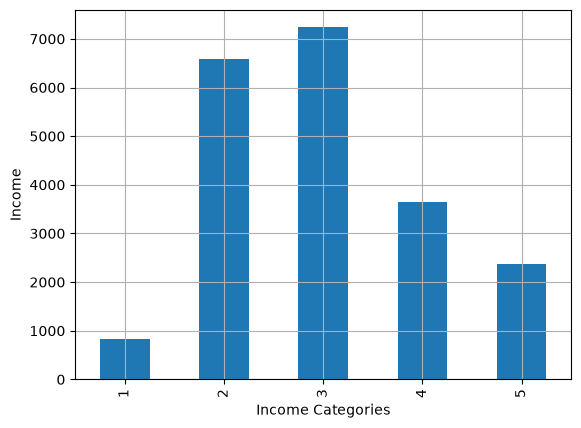

In [20]:
df["income_cat"].value_counts().sort_index().plot.bar(grid=True)
plt.xlabel("Income Categories")
plt.ylabel("Income")

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strata_data = []
for train_index, test_index in sss.split(df, df["income_cat"]): #10 divisions into train and test splits 
    train_data = df.iloc[train_index]
    test_data = df.iloc[test_index]
    strata_data.append([train_data, test_data])
strata_data    


[[       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
  12655    -121.46     38.52                29.0       3873.0           797.0   
  15502    -117.23     33.09                 7.0       5320.0           855.0   
  2908     -119.04     35.37                44.0       1618.0           310.0   
  14053    -117.13     32.75                24.0       1877.0           519.0   
  20496    -118.70     34.28                27.0       3536.0           646.0   
  ...          ...       ...                 ...          ...             ...   
  15174    -117.07     33.03                14.0       6665.0          1231.0   
  12661    -121.42     38.51                15.0       7901.0          1422.0   
  19263    -122.72     38.44                48.0        707.0           166.0   
  19140    -122.70     38.31                14.0       3155.0           580.0   
  19773    -122.14     39.97                27.0       1079.0           222.0   
  
         population  hous

In [22]:
for set_ in (train_data, test_data):
    set_.drop("income_cat", inplace=True, axis=1)

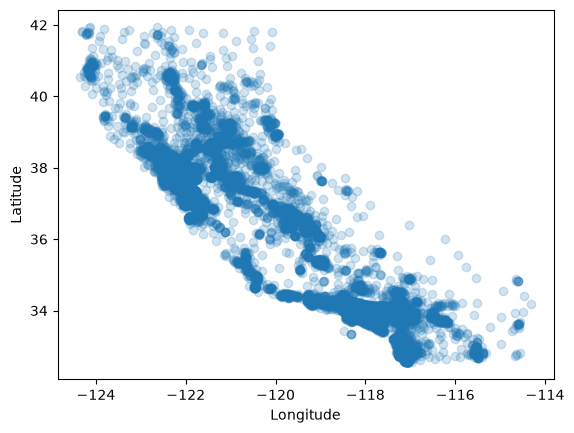

In [23]:
import matplotlib.pyplot as plt 
plt.scatter(df['longitude'], df['latitude'], alpha=0.2)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [25]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ids
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967,1.000000
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160,-0.924510
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623,-0.108292
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153,0.044573
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.069605
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650,0.099756
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843,0.055289
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075,-0.015276
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000,-0.046166
ids,1.000000,-0.924510,-0.108292,0.044573,0.069605,0.099756,0.055289,-0.015276,-0.046166,1.000000


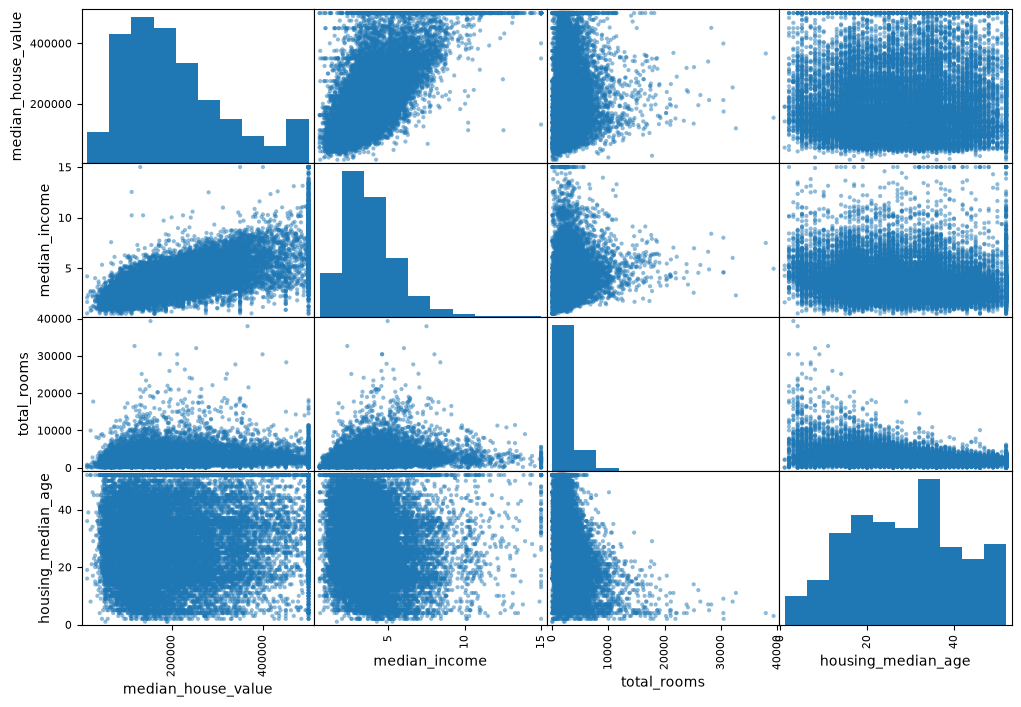

In [ ]:
from pandas.plotting import scatter_matrix
attribute = ["median_house_value","median_income","total_rooms","housing_median_age"] #strongly 
scatter_matrix(df[attribute], figsize=(12,8))
plt.show()

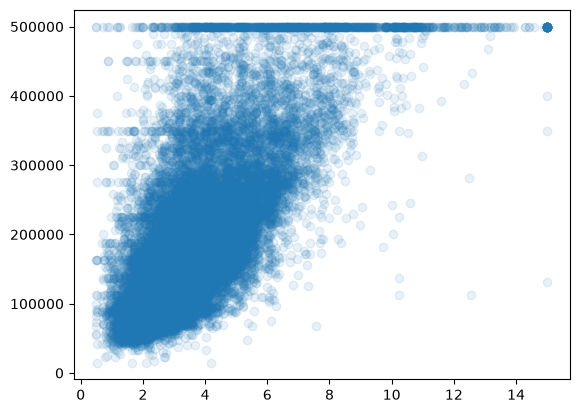

In [27]:
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.1)
plt.show()

In [28]:
df["rooms_per_house"] = df["total_rooms"]/df["households"]
df["bedrooms_ratio"] = df["total_bedrooms"]/df["total_rooms"]
df["people_per_house"] = df["population"]/df["households"]


In [30]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ids,income_cat,rooms_per_house,bedrooms_ratio,people_per_house
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12,5,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14,5,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15,5,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15,4,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15,3,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,-121050.52,2,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,-121170.51,2,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,-121180.57,2,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,-121280.57,2,5.329513,0.219892,2.123209


In [32]:
corr_matrix = df.corr(numeric_only=True)

In [34]:
corr_matrix["median_house_value"].sort_values()

bedrooms_ratio       -0.255880
latitude             -0.144160
ids                  -0.046166
longitude            -0.045967
population           -0.024650
people_per_house     -0.023737
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
rooms_per_house       0.151948
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64